# Exploratory Data Analysis (EDA)

**Data source:** `seaborn.load_dataset('tips')` — 244 restaurant transactions

**Goal:** Understand tipping behavior and how it relates to bill size and demographic/contextual factors

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf


In [2]:
# ---------------------------------------------------------------
# Global plot styling — applied once, affects every chart below
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,          # grid behind the data, not on top
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.frameon': False,
    'font.family': 'sans-serif',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

sns.set_palette('deep')   # consistent color palette for seaborn plots

## 01 — Data Overview


In [3]:
df = sns.load_dataset('tips')
df['tip_pct'] = df['tip'] / df['total_bill'] * 100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [4]:
print("Shape (rows, cols):", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())

Shape (rows, cols): (244, 8)

Data types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
tip_pct        float64
dtype: object

Missing values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
tip_pct       0
dtype: int64


In [5]:
df.describe().round(2)

,total_bill,tip,size,tip_pct
count,244.00,244.00,244.00,244.00
mean,19.79,3.00,2.57,16.08
std,8.90,1.38,0.95,6.11
min,3.07,1.00,1.00,3.56
25%,13.35,2.00,2.00,12.91
50%,17.80,2.90,2.00,15.48
75%,24.13,3.56,3.00,19.15
max,50.81,10.00,6.00,71.03


## 02 — Continuous Analysis


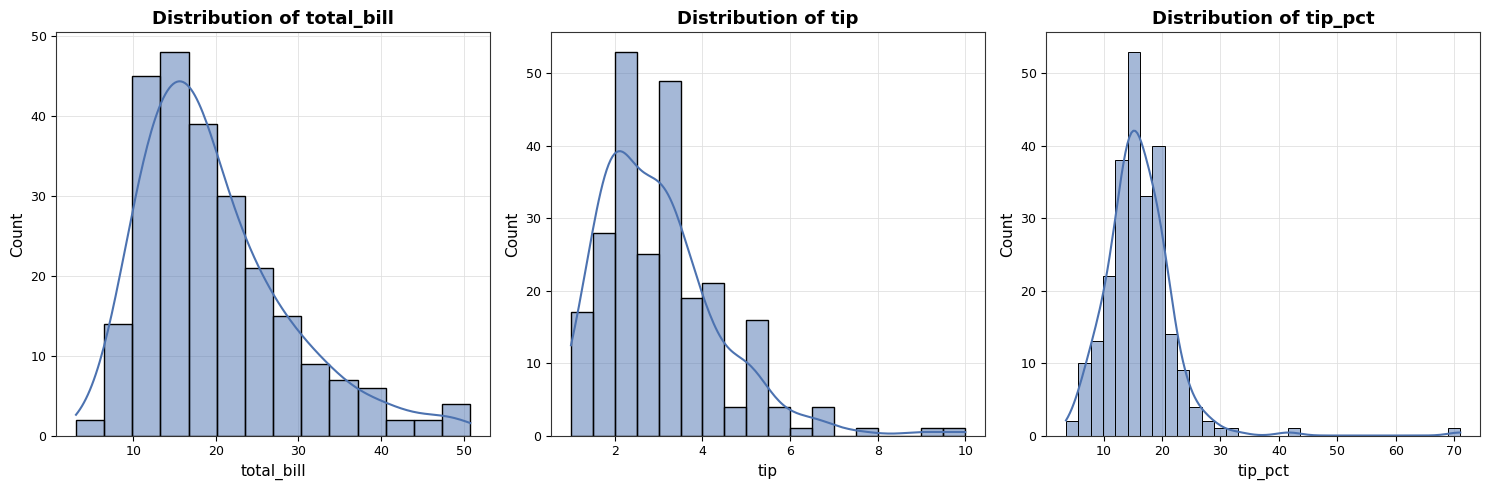

total_bill: skewness = 1.13
tip: skewness = 1.46
tip_pct: skewness = 3.33


In [6]:
# Distribution plots for the three main numeric variables

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cols = ['total_bill', 'tip', 'tip_pct']
for ax, col in zip(axes, cols):
    sns.histplot(data=df, x=col, ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()

plt.savefig('plots/distributions_total_bill_tip_tip_pct.png')
plt.show()

for c in ['total_bill', 'tip', 'tip_pct']:
    print(f"{c}: skewness = {stats.skew(df[c]):.2f}")

**Interpretation:**
- `total_bill` and `tip`: moderate positive skew — most bills are small/medium with a tail of larger bills.
- `tip_pct`: strong positive skew (skew ≈ 3.3) — a few unusually high tip percentages pull the mean up.

## 03 — Outlier Analysis


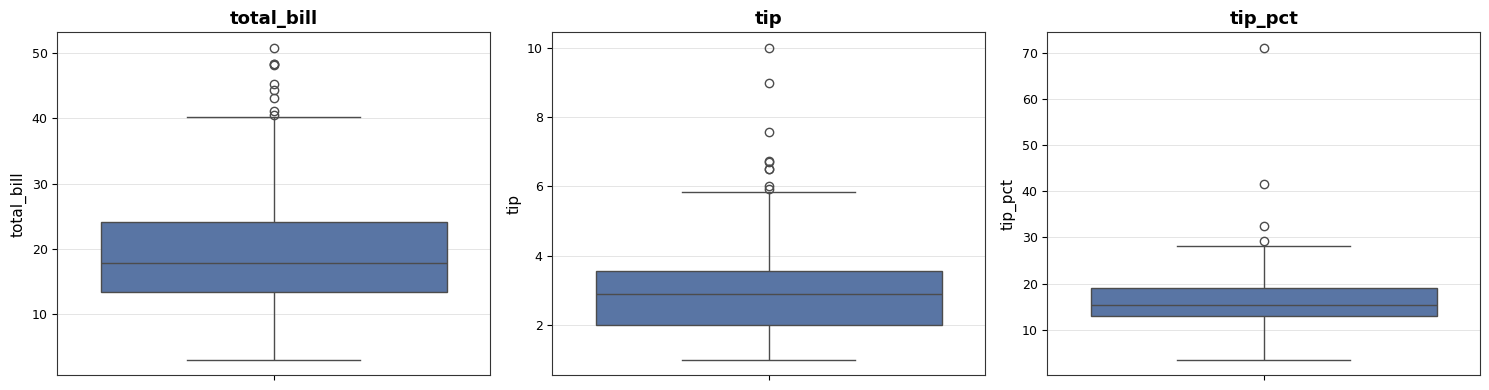

In [7]:
# Boxplots to check outliers in the three main numeric variables

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['total_bill', 'tip', 'tip_pct']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col, fontweight='bold')
plt.tight_layout()

plt.savefig('plots/boxplots_total_bill_tip_tip_pct.png')
plt.show()


The outliers in `tip_pct` are mostly small bills paired with a near-fixed tip, not data errors, so they were kept in the analysis.

## 04 — Categorical Analysis


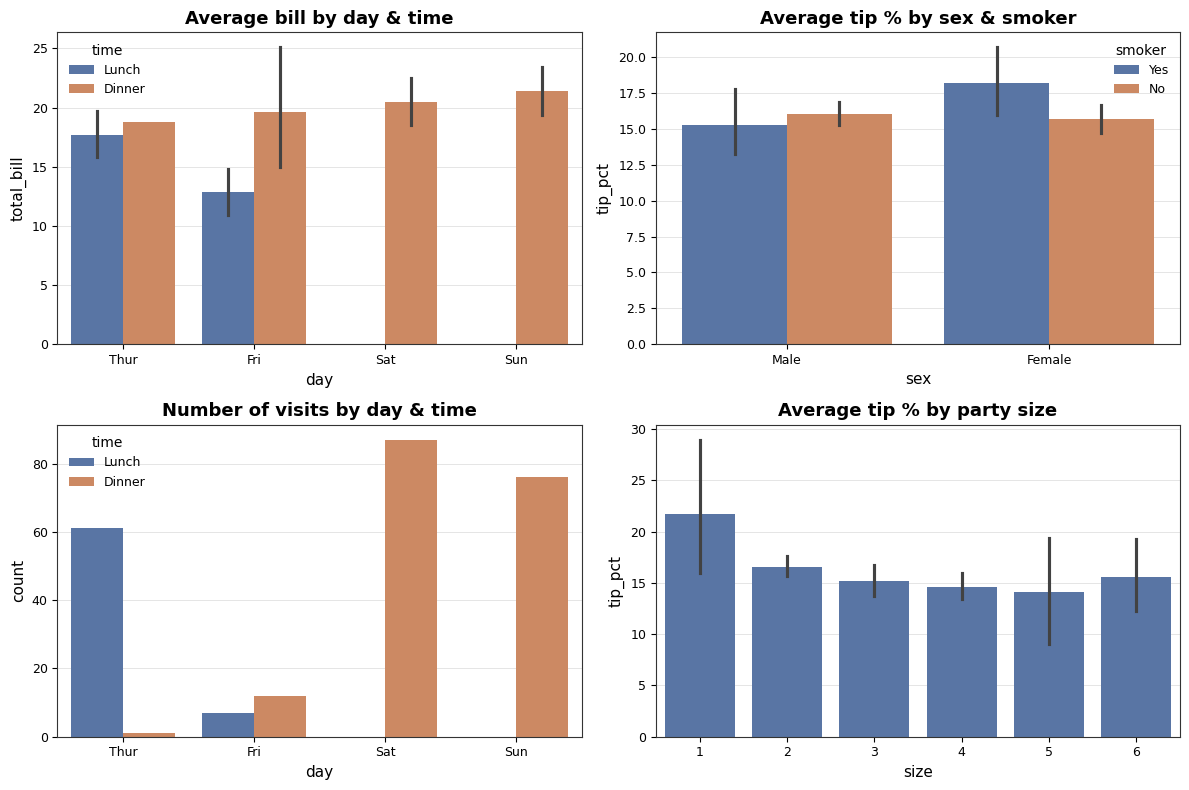

In [8]:
# Categorical breakdowns: bill/tip% by day, time, sex, smoker, party size

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.barplot(data=df, x='day', y='total_bill', hue='time', ax=axes[0,0],
            estimator=np.mean)
axes[0,0].set_title('Average bill by day & time', fontweight='bold')
sns.barplot(data=df, x='sex', y='tip_pct', hue='smoker', ax=axes[0,1], estimator=np.mean)
axes[0,1].set_title('Average tip % by sex & smoker', fontweight='bold')
sns.countplot(data=df, x='day', hue='time', ax=axes[1,0])
axes[1,0].set_title('Number of visits by day & time', fontweight='bold')
sns.barplot(data=df, x='size', y='tip_pct', ax=axes[1,1], estimator=np.mean)
axes[1,1].set_title('Average tip % by party size', fontweight='bold')
plt.tight_layout()

plt.savefig('plots/categorical_breakdowns.png')
plt.show()

In [9]:
for c in ['day', 'time', 'sex', 'smoker']:
    print(f"\n--- Average tip_pct by {c} ---")
    print(df.groupby(c, observed=True)['tip_pct'].mean().round(2))


--- Average tip_pct by day ---
day
Thur    16.13
Fri     16.99
Sat     15.32
Sun     16.69
Name: tip_pct, dtype: float64

--- Average tip_pct by time ---
time
Lunch     16.41
Dinner    15.95
Name: tip_pct, dtype: float64

--- Average tip_pct by sex ---
sex
Male      15.77
Female    16.65
Name: tip_pct, dtype: float64

--- Average tip_pct by smoker ---
smoker
Yes    16.32
No     15.93
Name: tip_pct, dtype: float64


**Initial observation:** the differences across days, between men and women, and between smokers
and non-smokers are all small. This suggests these factors may not actually be meaningful drivers 

## 05 — Bivariate Analysis

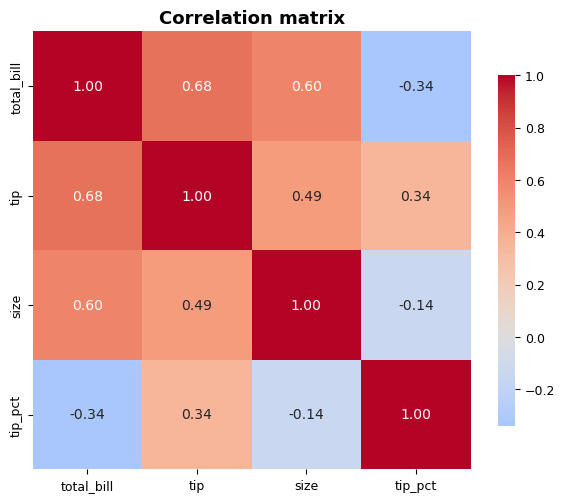

In [10]:
# Correlation matrix for the numeric variables

fig, ax = plt.subplots(figsize=(6, 5))
corr = df[['total_bill', 'tip', 'size', 'tip_pct']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix', fontweight='bold')
plt.tight_layout()

plt.savefig('plots/correlation_matrix.png')
plt.show()

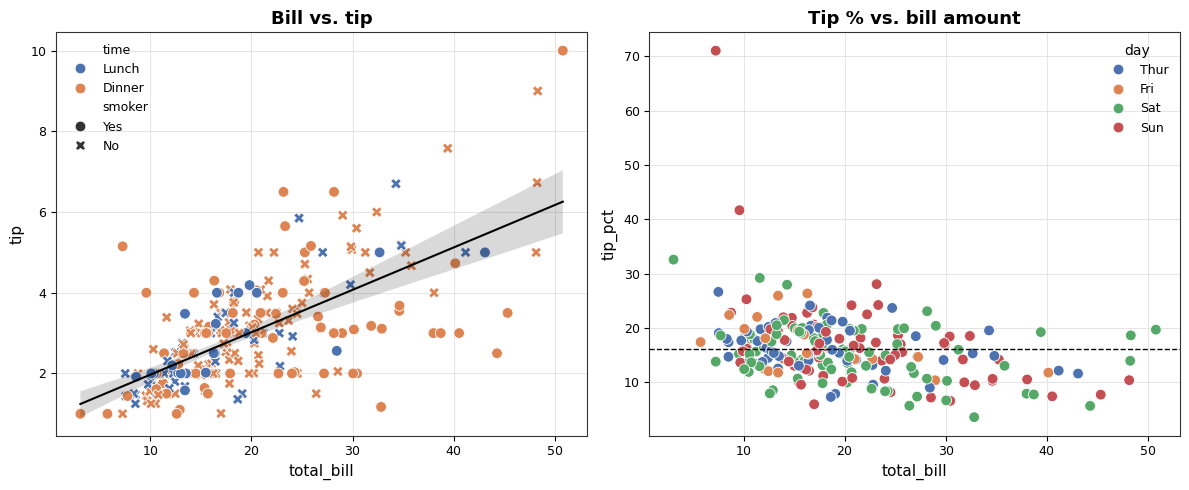

In [11]:
# Scatter plots: bill vs tip, and tip% vs bill amount

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', style='smoker', s=60, ax=axes[0])
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, ax=axes[0],
            color='black', line_kws={'linewidth': 1.5})
axes[0].set_title('Bill vs. tip', fontweight='bold')
sns.scatterplot(data=df, x='total_bill', y='tip_pct', hue='day', s=60, ax=axes[1])
axes[1].axhline(df['tip_pct'].mean(), color='black', linestyle='--', linewidth=1)
axes[1].set_title('Tip % vs. bill amount', fontweight='bold')
plt.tight_layout()

plt.savefig('plots/bivariate_bill_tip_relationships.png')
plt.show()

**Interpretation:**
- Strongest relationship in the data: **total_bill vs. tip** (r ≈ 0.68) — larger bills come with larger absolute tips.
- But `total_bill` vs. `tip_pct` is **weak and negative** (r ≈ -0.34) — customers with bigger bills tend to leave a *lower percentage* tip, even though the absolute amount is larger.
- `size` correlates strongly with `total_bill` as expected, but is nearly uncorrelated with `tip_pct`.

## 06 — Statistical Hypothesis Testing


In [12]:
# t-test: smoker vs non-smoker
g1 = df[df.smoker == 'Yes']['tip_pct']
g2 = df[df.smoker == 'No']['tip_pct']
t, p = stats.ttest_ind(g1, g2, equal_var=False)
print(f"Smoker vs Non-smoker (tip_pct): t={t:.3f}, p={p:.4f}")

# t-test: male vs female
g1 = df[df.sex == 'Male']['tip_pct']
g2 = df[df.sex == 'Female']['tip_pct']
t, p = stats.ttest_ind(g1, g2, equal_var=False)
print(f"Male vs Female (tip_pct): t={t:.3f}, p={p:.4f}")

# ANOVA: day
groups = [df[df.day == d]['tip_pct'] for d in df.day.unique()]
f, p = stats.f_oneway(*groups)
print(f"ANOVA across days (tip_pct): F={f:.3f}, p={p:.4f}")

# Pearson: total_bill vs tip
r, p = stats.pearsonr(df.total_bill, df.tip)
print(f"Pearson total_bill vs tip: r={r:.3f}, p={p:.6f}")

Smoker vs Non-smoker (tip_pct): t=0.411, p=0.6817
Male vs Female (tip_pct): t=-1.143, p=0.2542
ANOVA across days (tip_pct): F=0.848, p=0.4688
Pearson total_bill vs tip: r=0.676, p=0.000000


**Key result:** all the demographic differences (sex, smoker, day) in tip percentage are
**not statistically significant** (p > 0.05) — meaning the differences visible in the charts could well
be due to chance in this small sample (244 rows), not a real behavioral pattern. The only strong and
significant relationship is between **bill amount and tip** (p < 0.001).

## 07 — OLS Regression


In [13]:
model = smf.ols(
    formula='tip ~ total_bill',   
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           6.69e-34
Time:                        09:21:25   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9203      0.160      5.761      0.0

In [14]:
r2 = model.rsquared
adj_r2 = model.rsquared_adj
f_stat = model.fvalue
f_pval = model.f_pvalue
intercept = model.params['Intercept']
slope = model.params['total_bill']
p_slope = model.pvalues['total_bill']

print("=" * 55)
print("             E X E C U T I V E   S U M M A R Y             ")
print("=" * 55)
print(f"  • Model Performance (R²):     {r2*100:.1f}%")
print(f"  • Model Significance (p-val): {f_pval:.2e}  (F = {f_stat:.1f})")
print("-" * 55)
print("  MODEL EQUATION & IMPACT:")
print(f"  • Equation:  Tip = {intercept:.2f} + ({slope:.3f} × Total_Bill)")
print(f"  • Impact:    Each +$1.00 in Bill ➔ +${slope:.2f} in Tip")
print(f"  • P-Value:   {p_slope:.4f}  (Statistically Significant)")
print("=" * 55)

             E X E C U T I V E   S U M M A R Y             
  • Model Performance (R²):     45.7%
  • Model Significance (p-val): 6.69e-34  (F = 203.4)
-------------------------------------------------------
  MODEL EQUATION & IMPACT:
  • Equation:  Tip = 0.92 + (0.105 × Total_Bill)
  • Impact:    Each +$1.00 in Bill ➔ +$0.11 in Tip
  • P-Value:   0.0000  (Statistically Significant)


### Interpretation

**Total Bill has a significant positive relationship with Tip.**  
The model explains **45.7%** of the variation in tips, and each additional **1 USD** in the bill is associated with an expected **0.11 USD increase in tip** (p < 0.001).

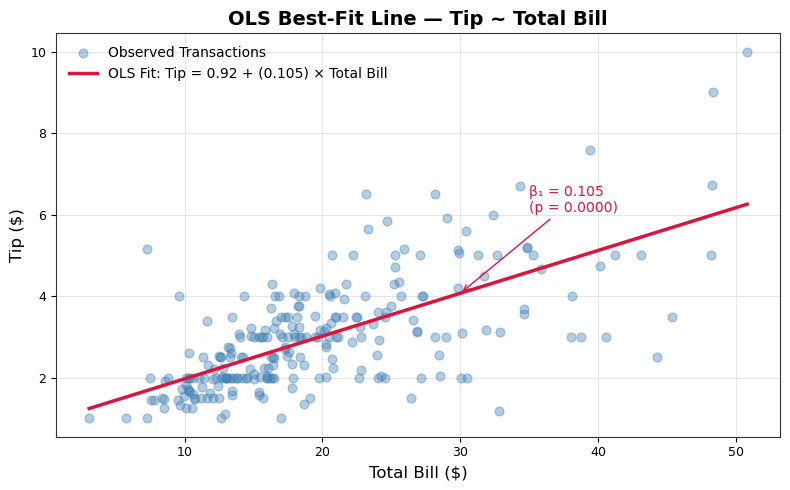

In [15]:
# OLS best-fit line with slope and p-value annotated

b0 = model.params['Intercept']
b1 = model.params['total_bill']
p_b1 = model.pvalues['total_bill']
# Generate prediction points across the range of total_bill
bill_range = np.linspace(df['total_bill'].min(), df['total_bill'].max(), 200)
predicted_tip = b0 + b1 * bill_range
fig, ax = plt.subplots(figsize=(8, 5))
# Actual data points
ax.scatter(
    df['total_bill'],
    df['tip'],
    alpha=0.4,
    color='steelblue',
    s=40,
    label='Observed Transactions'
)
# OLS fitted line
ax.plot(
    bill_range,
    predicted_tip,
    color='crimson',
    linewidth=2.5,
    label=f'OLS Fit: Tip = {b0:.2f} + ({b1:.3f}) × Total Bill'
)
# Annotate the slope on the chart
ax.annotate(
    f'β₁ = {b1:.3f}\n(p = {p_b1:.4f})',
    xy=(30, b0 + b1 * 30),
    xytext=(35, b0 + b1 * 30 + 2),
    fontsize=10,
    color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson')
)
ax.set_xlabel('Total Bill ($)', fontsize=12)
ax.set_ylabel('Tip ($)', fontsize=12)
ax.set_title('OLS Best-Fit Line — Tip ~ Total Bill', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()

plt.savefig('plots/ols_best_fit_line.png')
plt.show()

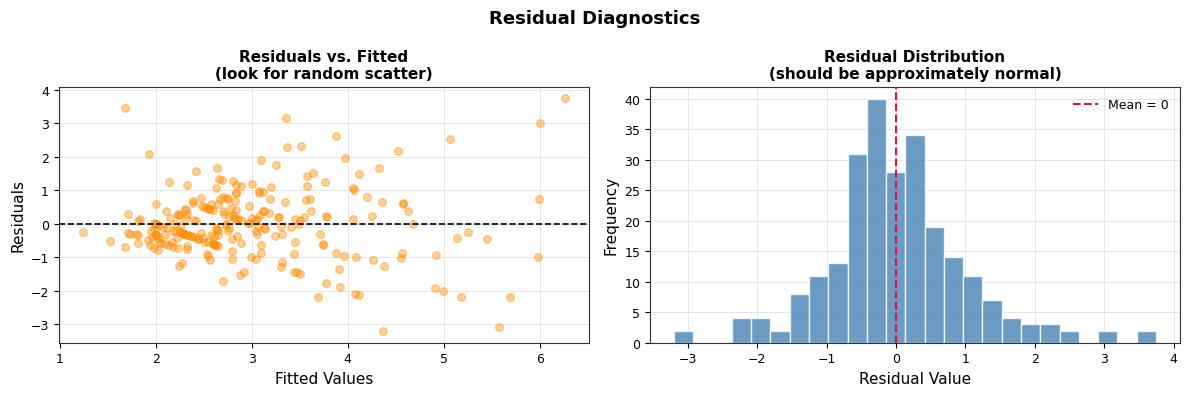

In [16]:
# Residual diagnostics: checks zero-mean, homoskedasticity, and normality

residuals = model.resid  
fitted = model.fittedvalues
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# --- plot 1: Residuals vs. Fitted values ---
# Look for: random scatter (good) vs. funnel shape / curve (bad)
axes[0].scatter(fitted, residuals, alpha=0.4, color='darkorange', s=30)
axes[0].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs. Fitted\n(look for random scatter)', fontsize=11)
# --- Plot 2: Histogram of residuals ---
# Look for: approximately normal bell shape centered at 0
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='crimson', linewidth=1.5, linestyle='--', label='Mean = 0')
axes[1].set_xlabel('Residual Value', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residual Distribution\n(should be approximately normal)', fontsize=11)
axes[1].legend()
plt.suptitle('Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()

# Save the figure before showing it
plt.savefig('plots/residual_diagnostics.png')
plt.show()

## 08 — Conclusions & Limitations

- The data is fully clean (no missing values), and the sample is relatively small (244 rows) — worth
  keeping in mind when generalizing any result.
- The one real driver of tip amount is **the bill amount itself** — a strong, consistent, statistically
  significant relationship across every test.
- Demographic factors (sex, smoker, day of week, meal time) **do not produce a real difference** in tip
  percentage, despite small visual differences in the charts — confirmed by both the statistical tests
  and the model together, not the model alone.
- Customers with larger bills tend to leave a slightly lower tip *percentage*, even though the absolute
  tip amount is larger.

> **Bottom line:** the OLS model here confirms numerically what the visual exploration and statistical
> tests already showed — it isn't the starting point of the analysis. That's the difference between a
> full data analysis and just running a model.